# Imports

In [3]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.gbm import GBMSimulator
from src.monte_carlo import MonteCarloPricer
from src.black_scholes import BlackScholes
from src.utils import get_hist_prices

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load SPY + Option Parameters

In [4]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S = float(prices.iloc[-1])
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))
mu_hat = float(returns.mean() * 252)
r = 0.03
q = 0.0

T = 0.25  # 3 months
K = S * 1.02  # 2% OTM

print(f"{ticker} S:", S)
print(f"Annualized vol:", sigma_hat)
print(f"Option: K={K}, T={T}, r={r}, q={q}")

SPY S: 750.3300170898438
Annualized vol: 0.17120037942121413
Option: K=765.3366174316407, T=0.25, r=0.03, q=0.0


# Vanilla Call Price

In [5]:
bs_vanilla = BlackScholes(S, K, T, r, sigma_hat, q=q)
vanilla_bs_price = bs_vanilla.call_price()

sim = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
mc = MonteCarloPricer(sim, r=r, q=q)

vanilla_mc_price = mc.price_european_call(K)

print(f"Vanilla Call: BS={vanilla_bs_price:.4f}, MC={vanilla_mc_price:.4f}")

Vanilla Call: BS=21.3957, MC=20.9681


# Asian Call Pricing

In [6]:
K_asian = S * 1.02

sim2 = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
mc2 = MonteCarloPricer(sim2, r=r, q=q)

asian_price = mc2.price_asian_call(K_asian)

print(f"Asian Call (K={K_asian:.2f}): MC price = {asian_price:.4f}")
print(f"Vanilla Call (same K): MC price = {vanilla_mc_price:.4f}")
print(f"Asian is cheaper than vanilla: {asian_price < vanilla_mc_price}")
print(f"Difference: {vanilla_mc_price - asian_price:.4f} ({(vanilla_mc_price - asian_price)/vanilla_mc_price*100:.2f}%)")

Asian Call (K=765.34): MC price = 9.4305
Vanilla Call (same K): MC price = 20.9681
Asian is cheaper than vanilla: True
Difference: 11.5375 (55.02%)


# Asian vs Vanilla

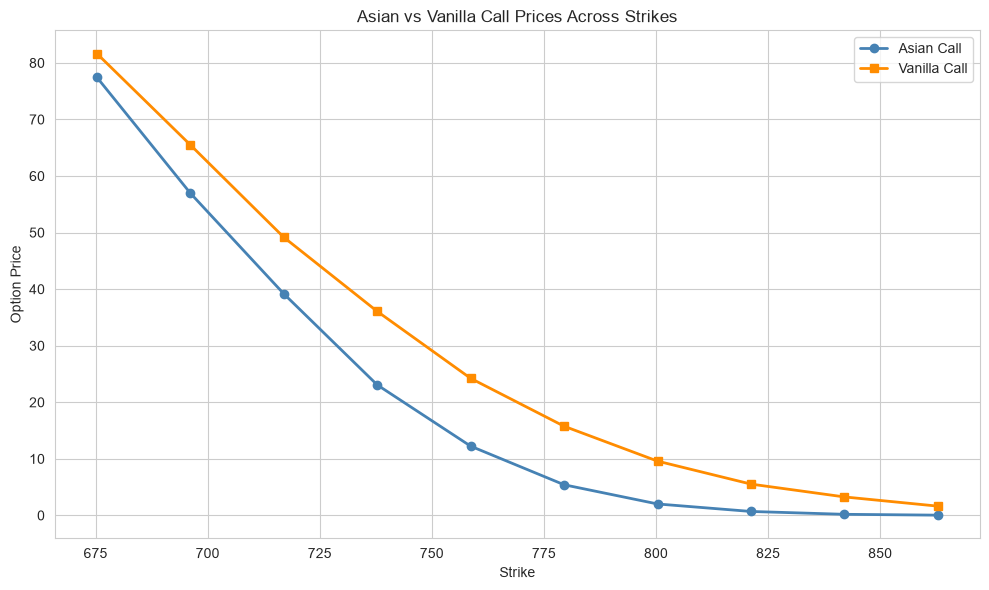

In [7]:
strikes = np.linspace(S * 0.9, S * 1.15, 10)
asian_prices = []
vanilla_prices = []

for K_val in strikes:
    #vanilla
    sim_v = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
    mc_v = MonteCarloPricer(sim_v, r=r, q=q)
    vanilla_prices.append(mc_v.price_european_call(K_val))
    
    #asian
    sim_a = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
    mc_a = MonteCarloPricer(sim_a, r=r, q=q)
    asian_prices.append(mc_a.price_asian_call(K_val))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(strikes, asian_prices, marker='o', label='Asian Call', color='steelblue', lw=2)
ax.plot(strikes, vanilla_prices, marker='s', label='Vanilla Call', color='darkorange', lw=2)
ax.set_xlabel('Strike')
ax.set_ylabel('Option Price')
ax.set_title('Asian vs Vanilla Call Prices Across Strikes')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Barrier Call Pricing

In [8]:
K_barrier = S * 1.02
barrier = S * 1.10  # 10% above current price

sim_bo = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
mc_bo = MonteCarloPricer(sim_bo, r=r, q=q)
barrier_knock_out = mc_bo.price_barrier_call(K_barrier, barrier, barrier_type="knock_out")

sim_bi = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
mc_bi = MonteCarloPricer(sim_bi, r=r, q=q)
barrier_knock_in = mc_bi.price_barrier_call(K_barrier, barrier, barrier_type="knock_in")

print(f"Barrier (knock-out) Call: {barrier_knock_out:.4f}")
print(f"Barrier (knock-in) Call:  {barrier_knock_in:.4f}")
print(f"Vanilla Call:             {vanilla_mc_price:.4f}")
print(f"Knock-out < Vanilla: {barrier_knock_out < vanilla_mc_price}")
print(f"Knock-in < Vanilla: {barrier_knock_in < vanilla_mc_price}")

Barrier (knock-out) Call: 4.3937
Barrier (knock-in) Call:  16.9324
Vanilla Call:             20.9681
Knock-out < Vanilla: True
Knock-in < Vanilla: True


# Barrier Price vs Barrier Level

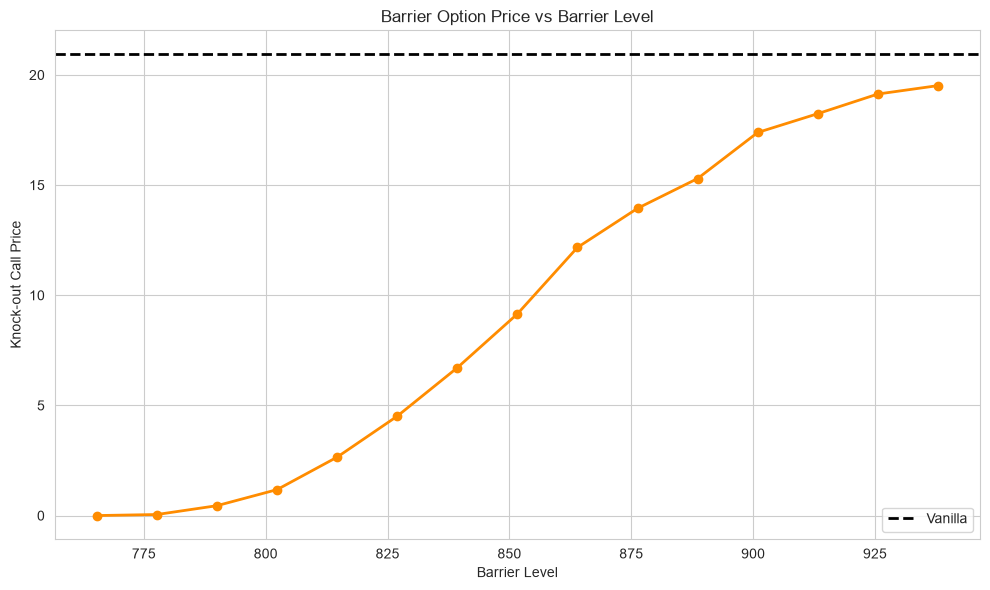

In [9]:
barrier_levels = np.linspace(S * 1.02, S * 1.25, 15)
barrier_prices = []

for b in barrier_levels:
    sim_b = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
    mc_b = MonteCarloPricer(sim_b, r=r, q=q)
    p = mc_b.price_barrier_call(K_barrier, b, barrier_type="knock_out")
    barrier_prices.append(p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(barrier_levels, barrier_prices, marker='o', color='darkorange', lw=2)
ax.axhline(vanilla_mc_price, color='black', lw=2, linestyle='--', label='Vanilla')
ax.set_xlabel('Barrier Level')
ax.set_ylabel('Knock-out Call Price')
ax.set_title("Barrier Option Price vs Barrier Level")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Barrier Type Comparison

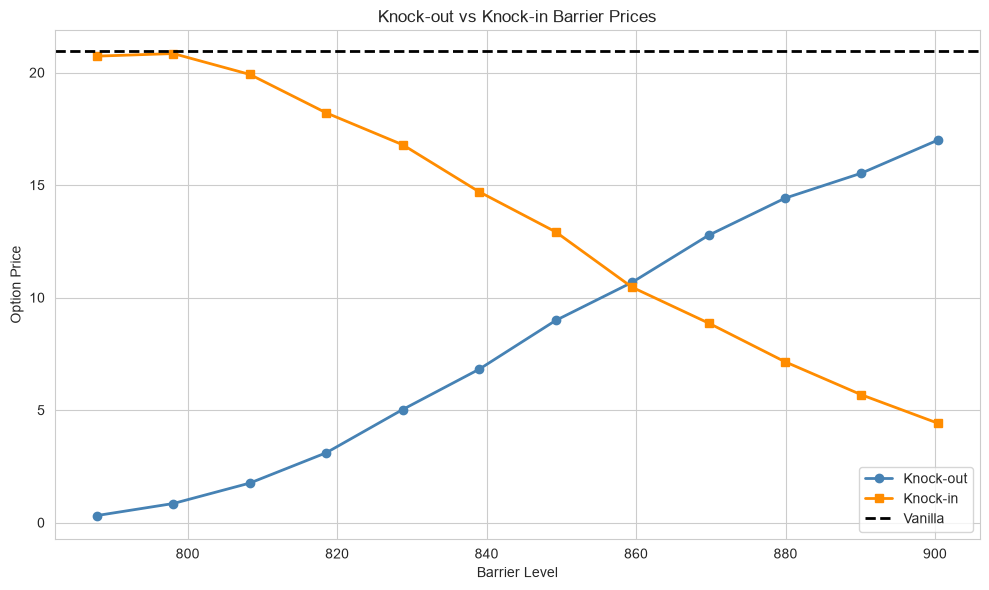

In [10]:
barrier_levels2 = np.linspace(S * 1.05, S * 1.20, 12)
knock_out_prices = []
knock_in_prices = []

for b in barrier_levels2:
    #knock-out
    sim_ko = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
    mc_ko = MonteCarloPricer(sim_ko, r=r, q=q)
    knock_out_prices.append(mc_ko.price_barrier_call(K_barrier, b, barrier_type="knock_out"))
    
    #knock-in
    sim_ki = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=1/252, n_paths=10000)
    mc_ki = MonteCarloPricer(sim_ki, r=r, q=q)
    knock_in_prices.append(mc_ki.price_barrier_call(K_barrier, b, barrier_type="knock_in"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(barrier_levels2, knock_out_prices, marker='o', label='Knock-out', color='steelblue', lw=2)
ax.plot(barrier_levels2, knock_in_prices, marker='s', label='Knock-in', color='darkorange', lw=2)
ax.axhline(vanilla_mc_price, color='black', lw=2, linestyle='--', label='Vanilla')
ax.set_xlabel('Barrier Level')
ax.set_ylabel('Option Price')
ax.set_title("Knock-out vs Knock-in Barrier Prices")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()